In [1]:
import os
from dotenv import load_dotenv
import warnings

load_dotenv()
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore")

In [13]:
from typing import cast, Any
# from typing import Dict, List, Optional, Tuple
import numpy as np
from numpy.typing import NDArray
import pandas as pd
import matplotlib.pyplot as plt
import umap
from sklearn.mixture import GaussianMixture

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

RANDOM_SEED = 42

In [3]:
# 문서 로드
loader = PyMuPDFLoader("./data/2026_gov.pdf")
docs = loader.load()

# 청크 분할
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(docs[41:95])
leaf_texts = [chunk.page_content for chunk in chunks]

print(f"레벨 0 청크: {len(leaf_texts)}개")
print(f"평균 크기: {np.mean([len(t) for t in leaf_texts]):.0f}자")

레벨 0 청크: 88개
평균 크기: 364자


In [4]:
# ---------------------------------------------------
# UMAP 차원 축소
# ---------------------------------------------------

def global_cluster_embeddings(
    embeddings: NDArray[np.float64], 
    dim: int,
    n_neighbors: int | None = None, 
    metric: str = "cosine"
) -> NDArray[np.float64]:
    """전역 차원 축소: 전체 데이터의 큰 구조를 파악해요."""
    
    # 1. 입력 데이터에 이상한 값(NaN, Inf)이 있는지 확인해봐! (충돌의 주범!)
    if np.isnan(embeddings).any() or np.isinf(embeddings).any():
        print("앗! 주인님, 데이터에 NaN이나 Inf가 들어있어! 이러면 커널이 죽는다구!")
        # 적절한 처리가 필요하겠지만 일단 넘어가줄게!
    
    if n_neighbors is None:
        n_neighbors = max(2, int((len(embeddings) - 1) ** 0.5))
    
    return cast(
        NDArray[np.float64],
        umap.UMAP(
            n_neighbors=n_neighbors, 
            n_components=dim, 
            metric=metric,
            random_state=42,
            n_jobs=1  # ★ 중요! 맥에서 커널 충돌나면 이걸 1로 설정하는 게 국룰이야!
        ).fit_transform(embeddings)
    )



def local_cluster_embeddings(
    embeddings: NDArray[np.float64], 
    dim: int,
    num_neighbors: int = 10, 
    metric: str = "cosine"
) -> NDArray[np.float64]:
    """로컬 차원 축소: 특정 클러스터 내에서 세밀한 구조를 발견해요."""
    n_neighbors = max(2, min(len(embeddings) - 1, num_neighbors))
    
    return cast(
        NDArray[np.float64],
        umap.UMAP(
            n_neighbors=n_neighbors, n_components=dim, metric=metric
        ).fit_transform(embeddings)
    )


In [5]:
# ---------------------------------------------------
# BIC 기반 최적 클러스터 수 + GMM 클러스터링
# ---------------------------------------------------

def get_optimal_clusters(
    embeddings: NDArray[np.float64], max_clusters: int = 50, random_state: int = RANDOM_SEED
) -> int:
    """BIC 점수가 가장 낮은 클러스터 수를 반환해요."""
    max_clusters = min(max_clusters, len(embeddings))
    n_clusters = np.arange(1, max_clusters)
    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        bics.append(gm.bic(embeddings))
    return n_clusters[np.argmin(bics)]


def GMM_cluster(embeddings: NDArray[np.float64], threshold: float, random_state: int = 0):
    """소프트 클러스터링: threshold 초과 확률의 클러스터에 할당해요."""
    n_clusters = get_optimal_clusters(embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)
    probs = gm.predict_proba(embeddings)
    labels = [np.where(prob > threshold)[0] for prob in probs]
    return labels, n_clusters

In [6]:
# ---------------------------------------------------
# 계층적 클러스터링: 전역 → 로컬 2단계
# ---------------------------------------------------

def perform_clustering(
    embeddings: NDArray[np.float64], dim: int, threshold: float,
) -> list[NDArray[np.float64]]:
    if len(embeddings) <= dim + 1:
        return [np.array([0], dtype=np.float64) for _ in range(len(embeddings))]

    # 전역 차원 축소 + 클러스터링
    reduced_global = global_cluster_embeddings(embeddings, dim)
    global_clusters, n_global = GMM_cluster(reduced_global, threshold)

    all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
    total_clusters = 0

    for i in range(n_global):
        # 현재 전역 클러스터에 속하는 임베딩 추출
        mask = np.array([i in gc for gc in global_clusters])
        cluster_embs = embeddings[mask]

        if len(cluster_embs) == 0:
            continue
        if len(cluster_embs) <= dim + 1:
            local_clusters = [np.array([0]) for _ in cluster_embs]
            n_local = 1
        else:
            # 로컬 차원 축소 + 클러스터링
            reduced_local = local_cluster_embeddings(cluster_embs, dim)
            local_clusters, n_local = GMM_cluster(reduced_local, threshold)

        for j in range(n_local):
            local_embs = cluster_embs[np.array([j in lc for lc in local_clusters])]
            indices = np.where((embeddings == local_embs[:, None]).all(-1))[1]
            for idx in indices:
                all_local_clusters[idx] = np.append(
                    all_local_clusters[idx], j + total_clusters
                )
        total_clusters += n_local

    return all_local_clusters

In [7]:
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
text_embedding_np = np.array(embedding_model.embed_documents(leaf_texts))
text_embedding_np.shape

(88, 1536)

In [8]:
# 2차원 차원축소

reduced_2d = global_cluster_embeddings(text_embedding_np, dim=2)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


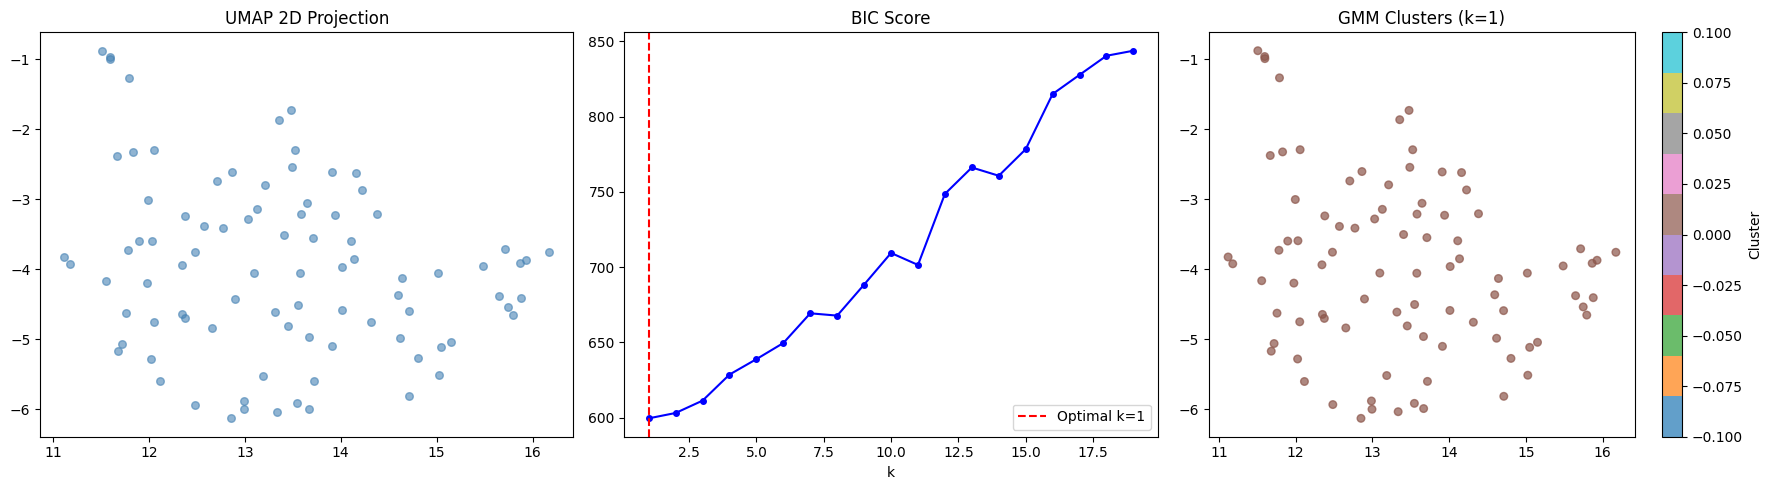

  Cluster 0: 88개


In [11]:
# ---------------------------------------------------
# BIC 곡선 + 클러스터 산점도 시각화
# ---------------------------------------------------
max_k = min(20, len(reduced_2d))
bics = []
for n in range(1, max_k):
    gm = GaussianMixture(n_components=n, random_state=RANDOM_SEED)
    gm.fit(reduced_2d)
    bics.append(gm.bic(reduced_2d))
optimal_k = np.argmin(bics) + 1

gm = GaussianMixture(n_components=optimal_k, random_state=RANDOM_SEED)
gm.fit(reduced_2d)
cluster_labels = gm.predict(reduced_2d)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(reduced_2d[:, 0], reduced_2d[:, 1], alpha=0.6, s=30, c="steelblue")
axes[0].set_title("UMAP 2D Projection")

axes[1].plot(range(1, max_k), bics, "bo-", markersize=4)
axes[1].axvline(x=optimal_k, color="r", linestyle="--", label=f"Optimal k={optimal_k}")
axes[1].set_title("BIC Score")
axes[1].set_xlabel("k")
axes[1].legend()

scatter = axes[2].scatter(reduced_2d[:, 0], reduced_2d[:, 1], c=cluster_labels, cmap="tab10", alpha=0.7, s=30)
axes[2].set_title(f"GMM Clusters (k={optimal_k})")
plt.colorbar(scatter, ax=axes[2], label="Cluster")

plt.tight_layout()
plt.show()

for i in range(optimal_k):
    print(f"  Cluster {i}: {(cluster_labels == i).sum()}개")

In [ ]:
# 클러스터링 함수를 조합해서 임베딩 -> 클러스터링 -> 요약을 재귀적으로 반복

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


def embed(texts):
    return np.array(embedding_model.embed_documents(texts))


def embed_cluster_texts(texts):
    text_embeddings_np = embed(texts)
    cluster_labels = perform_clustering(text_embeddings_np, 10, 0.1)
    df = pd.DataFrame()
    df["text"] = texts
    df["embd"] = list(text_embeddings_np)
    df["cluster"] = cast(Any, cluster_labels)

    return df


def fmt_txt(df):
    return "\n---\n".join(df["text"].tolist())

In [ ]:
# ---------------------------------------------------
# 임베딩 + 클러스터링 + 요약 통합 함수
# ---------------------------------------------------

def embed_cluster_summarize_texts(texts, level):
    # 임베딩 + 클러스터링
    df_clusters = embed_cluster_texts(texts)

    # 소프트 클러스터링 확장 (1개 데이터가 여러 클러스터에 소속 가능)
    expanded_list = []
    for _, row in df_clusters.iterrows():
        for cluster in row["cluster"]:
            expanded_list.append({"text": row["text"], "embd": row["embd"], "cluster": cluster})
    expanded_df = pd.DataFrame(expanded_list)
    all_clusters = expanded_df["cluster"].unique()
    print(f"  Level {level}: {len(all_clusters)} clusters")

    # 클러스터별 LLM 요약
    summary_prompt = PromptTemplate.from_template("""
    다음 문서들의 핵심 내용을 하나의 일관된 요약으로 통합하세요.

    문서:
    {context}

    통합 요약:
    """)
    chain = summary_prompt | llm | StrOutputParser()

    summaries = []
    for i in all_clusters:
        df_cluster = expanded_df[expanded_df["cluster"] == i]
        summaries.append(chain.invoke({"context": fmt_txt(df_cluster)}))

    df_summary = pd.DataFrame({
        "summaries": summaries,
        "level": [level] * len(summaries),
        "cluster": list(all_clusters),
    })
    return df_clusters, df_summary

In [15]:
# ---------------------------------------------------
# 재귀적 트리 구축
# ---------------------------------------------------

def recursive_embed_cluster_summarize(texts, level=1, n_levels=3):
    results = {}
    df_clusters, df_summary = embed_cluster_summarize_texts(texts, level)
    results[level] = (df_clusters, df_summary)

    unique_clusters = df_summary["cluster"].nunique()
    if level < n_levels and unique_clusters > 1:
        new_texts = df_summary["summaries"].tolist()
        results.update(recursive_embed_cluster_summarize(new_texts, level + 1, n_levels))

    return results

In [16]:
res = recursive_embed_cluster_summarize(leaf_texts, level=1, n_levels=3)

res

  Level 1: 16 clusters
  Level 2: 3 clusters
  Level 3: 1 clusters


{1: (                                                 text  \
  0   1\n2026년부터 이렇게 달라집니다\n2026년부터\n이렇게 달라집니다\n금융·재...   
  1   2\n금융·재정·조세\n제 1 장\n통합고용세액공제 공제액 구조 개편 및 사후관리 ...   
  2   900\n500\n3년차\n1,700 2,000\n900\n-\n기본\n1년차\n4...   
  3   3\n2026년부터 이렇게 달라집니다\n \n자녀 수에 따라 보육수당 비과세 한도 ...   
  4   4\n금융·재정·조세\n제 1 장\n자녀 수에 따라 신용카드 등 소득공제 한도 확대...   
  ..                                                ...   
  83  53\n2026년부터 이렇게 달라집니다\n금융위원회 누리집>보도자료>“내년부터 상호...   
  84  상호금융권 이용 금융소비자들이 유리한 대출로 갈아타거나 대출금을 조기에 상환하는데 ...   
  85  다른 금융권과 동일한 중도상환 수수료 개편방안을 적용\n주요내용\n\t · 상호금...   
  86  54\n원자력안전관리부담금 산정기준 개편\n원자력안전위원회 \nwww.nssc.go...   
  87  구체화하였습니다.\n원자력안전관리부담금 산정기준 합리화\n추진배경\n부담금 부과ㆍ징...   
  
                                                   embd cluster  
  0   [0.006961822509765625, -0.05487060546875, 0.05...   [2.0]  
  1   [0.01611328125, 0.0091705322265625, 0.04089355...   [4.0]  
  2   [0.0389404296875, 0.0170135498046875, 0.024887...   [4.0]  
  3   [0.0277404785156

In [35]:
print(res[3][1].summaries[0])

results = res

2026년 1월 1일부터 시행되는 주요 금융 및 세제 개편안은 경제 활성화와 사회적 형평성을 도모하기 위해 다양한 세제 혜택과 지원을 강화하는 내용을 담고 있습니다. 주요 내용은 다음과 같습니다:

1. **세금 및 비과세 조정**: 농협, 수협, 산림조합의 조합원 및 총급여 7천만원 이하 준조합원에 대한 예탁금과 출자금의 이자 및 배당소득 비과세 적용기한이 3년 연장되며, 초과 준조합원은 저율 분리과세가 적용됩니다.

2. **청년미래적금 신설**: 청년 자산형성을 지원하기 위해 청년미래적금이 도입되며, 정부 기여금 지원비율이 일반형 6%, 우대형 12%로 설정됩니다.

3. **연금소득 원천징수세율 인하**: 사적연금을 종신 수령할 경우 원천징수세율이 4%에서 3%로 인하됩니다.

4. **고향사랑기부금 세액공제 확대**: 고향사랑기부금에 대한 세액공제율이 15%에서 40%로 상향 조정됩니다.

5. **자녀 양육 지원**: 보육수당 비과세 한도가 자녀 1인당 월 20만원으로 확대되고, 초등학교 저학년 자녀의 예체능 학원비가 교육비 세액공제 대상에 포함됩니다.

6. **고배당기업 배당소득 분리과세 도입**: 고배당기업으로부터 받은 배당소득에 대해 분리과세가 적용됩니다.

7. **중소기업 및 사회적기업 지원**: 생계형 창업중소기업의 세액감면 기준금액이 상향 조정되고, 위기지역 창업기업에 대한 세액감면이 신설됩니다.

8. **주택 관련 세제 혜택**: 1세대 1주택 특례 대상지역이 확대되고, 비수도권의 인구감소관심지역에서도 주택을 추가 취득할 경우 세제 혜택을 받을 수 있습니다.

9. **금융투자소득세 및 증권거래세 조정**: 증권거래세율이 인상되며, 상장사의 영문공시 의무가 확대됩니다.

10. **소비자 보호 및 세제 형평성 강화**: 영세 개인사업자를 위한 체납액 징수특례 확대, 중도상환 수수료 인하, 담배 관련 규제 강화 등이 포함됩니다.

이러한 개편안들은 청년층의 자산형성 지원, 기부 장려, 노후 생활 안정, 자녀 양육 부담 완화, 중소기업

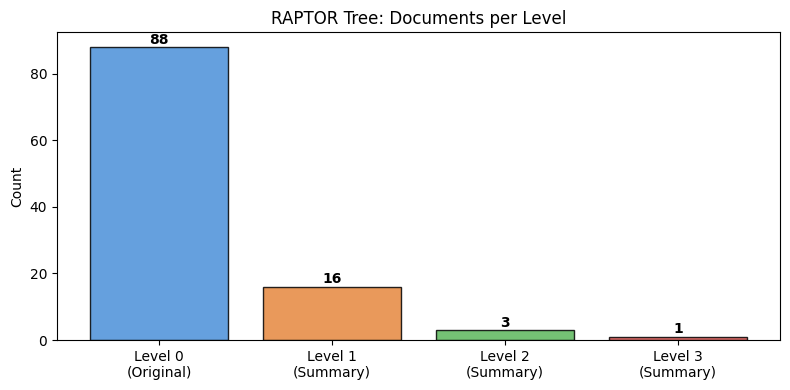


Level 1 샘플: 2026년부터 시행되는 주요 금융 및 세제 개편안은 다음과 같습니다. 

1. **세금 및 비과세 조정**: 농협, 수협, 산림조합의 조합원 및 총급여 7천만원 이하의 준조합원에 대한 예탁금과 출자금의 이자 및 배당...

Level 2 샘플: 2026년 1월 1일부터 시행되는 주요 금융 및 세제 개편안은 다양한 분야에서 세제 혜택과 지원을 강화하여 경제 활성화와 사회적 형평성을 도모하는 내용을 담고 있습니다. 

1. **세금 및 비과세 조정**: 농협,...

Level 3 샘플: 2026년 1월 1일부터 시행되는 주요 금융 및 세제 개편안은 경제 활성화와 사회적 형평성을 도모하기 위해 다양한 세제 혜택과 지원을 강화하는 내용을 담고 있습니다. 주요 내용은 다음과 같습니다:

1. **세금 및...


In [36]:
# ---------------------------------------------------
# 트리 레벨별 통계 시각화
# ---------------------------------------------------
level_names = ["Level 0\n(Original)"]
level_counts = [len(leaf_texts)]
colors = ["#4a90d9", "#e6873e", "#5cb85c", "#d9534f"]

for level in sorted(results.keys()):
    n = len(results[level][1])
    level_names.append(f"Level {level}\n(Summary)")
    level_counts.append(n)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(level_names, level_counts, color=colors[:len(level_names)], edgecolor="black", alpha=0.85)
for bar, count in zip(bars, level_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(count), ha='center', fontweight='bold')
ax.set_title("RAPTOR Tree: Documents per Level")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# 요약 샘플
for level in sorted(res.keys()):
    s = results[level][1]["summaries"].iloc[0]
    print(f"\nLevel {level} 샘플: {s[:120]}...")

In [37]:
# ---------------------------------------------------
# 모든 레벨 통합 벡터스토어
# ---------------------------------------------------
all_texts = leaf_texts.copy()
for level in sorted(results.keys()):
    all_texts.extend(results[level][1]["summaries"].tolist())

vectorstore = FAISS.from_texts(texts=all_texts, embedding=embedding_model)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

print(f":white_check_mark: 벡터스토어: 레벨 0({len(leaf_texts)}) + 요약({len(all_texts) - len(leaf_texts)}) = {len(all_texts)}개")

# ---------------------------------------------------
# RAPTOR RAG 체인
# ---------------------------------------------------
raptor_prompt = PromptTemplate.from_template(
    """문맥을 참고하여 질문에 답하세요.

문맥:
{context}

질문: {question}

답변:"""
)

raptor_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | raptor_prompt
    | llm
    | StrOutputParser()
)
print(":white_check_mark: RAPTOR RAG 체인 생성 완료")

:white_check_mark: 벡터스토어: 레벨 0(88) + 요약(20) = 108개
:white_check_mark: RAPTOR RAG 체인 생성 완료


In [38]:
# 질문 1: 개괄적 질문
q1 = "이 문서의 전반적인 주제는 무엇인가요?"
print(f"질문: {q1}")
print("=" * 60)

retrieved = retriever.invoke(q1)
print("\n검색된 문서:")
for i, doc in enumerate(retrieved, 1):
    tag = "요약" if doc.page_content not in leaf_texts else "원본"
    print(f"  [{i}] [{tag}] {doc.page_content[:100]}...")

print(f"\n답변:\n{raptor_chain.invoke(q1)}")

질문: 이 문서의 전반적인 주제는 무엇인가요?

검색된 문서:
  [1] [요약] 2026년 1월 1일부터 시행되는 주요 금융 및 세제 개편안은 경제 활성화와 사회적 형평성을 도모하기 위해 다양한 세제 혜택과 지원을 강화하는 내용을 담고 있습니다. 주요 내용은 ...
  [2] [요약] 2026년 1월 1일부터 시행되는 주요 금융 및 세제 개편안은 다양한 분야에서 세제 혜택과 지원을 강화하여 경제 활성화와 사회적 형평성을 도모하는 내용을 담고 있습니다. 

1. ...
  [3] [원본] 개정내용은 2026년 1월 1일 이후 가입하는 분부터 적용됩니다.
상호금융 예탁금ㆍ출자금 비과세 적용기한 연장 및 적용범위 합리화 
추진배경
농ㆍ어ㆍ임업인 지원 및 과세형평 제고
...
  [4] [요약] 2026년 1월 1일부터 시행되는 여러 세제 개편안이 발표되었다. 주요 내용은 다음과 같다:

1. **고배당기업 배당소득 분리과세 도입**: 고배당기업으로부터 받은 배당소득에 대...
  [5] [원본] 20
영상콘텐츠 세제지원 확대
재정경제부
www.moef.go.kr
영상콘텐츠산업의 글로벌 경쟁력 지원을 위하여 영상콘텐츠 제작비용 세액공제의 기본공제율이 
추가공제율과 일치되도록...

답변:
이 문서의 전반적인 주제는 2026년 1월 1일부터 시행되는 주요 금융 및 세제 개편안에 대한 내용으로, 경제 활성화와 사회적 형평성을 도모하기 위해 다양한 세제 혜택과 지원을 강화하는 방안들을 설명하고 있습니다. 주요 내용으로는 세금 조정, 청년 자산형성 지원, 자녀 양육 지원, 중소기업 및 사회적기업 지원, 주택 관련 세제 혜택 등이 포함되어 있습니다.


In [39]:
# 질문 2: 세부적 질문
q2 = "영상콘텐츠 제작비용 세액공제의 구체적인 공제율은?"
print(f"질문: {q2}")
print("=" * 60)

retrieved = retriever.invoke(q2)
print("\n검색된 문서:")
for i, doc in enumerate(retrieved, 1):
    tag = "요약" if doc.page_content not in leaf_texts else "원본"
    print(f"  [{i}] [{tag}] {doc.page_content[:100]}...")

print(f"\n답변:\n{raptor_chain.invoke(q2)}")

질문: 영상콘텐츠 제작비용 세액공제의 구체적인 공제율은?

검색된 문서:
  [1] [원본] 20
영상콘텐츠 세제지원 확대
재정경제부
www.moef.go.kr
영상콘텐츠산업의 글로벌 경쟁력 지원을 위하여 영상콘텐츠 제작비용 세액공제의 기본공제율이 
추가공제율과 일치되도록...
  [2] [원본] 2
금융·재정·조세
제 1 장
통합고용세액공제 공제액 구조 개편 및 사후관리 합리화
시행일: 2026년 1월 1일
자세한 내용은p.008
• 장기고용 유인강화 및 납세 협력 비용...
  [3] [원본] 주요내용
웹툰콘텐츠 제작비용에 대해 소득세·법인세 세액공제 신설
시행일
2026년 1월 1일 이후 발생하는 비용 분부터 적용
재정경제부 누리집>보도자료>2025년 세제개편안 발표(...
  [4] [원본] 9
2026년부터 이렇게 달라집니다
웹툰콘텐츠 제작비용 세액공제 신설 
재정경제부
www.moef.go.kr
웹툰콘텐츠산업의 글로벌 경쟁력 지원을 위하여 웹툰콘텐츠 제작비용에 대한...
  [5] [요약] 2026년 1월 1일부터 시행되는 새로운 세제 개편안은 통합고용세액공제의 공제액 구조 개편, 웹툰 및 영상콘텐츠 제작비용에 대한 세액공제 신설, 그리고 무주택 주말부부에 대한 월세...

답변:
영상콘텐츠 제작비용 세액공제의 구체적인 공제율은 대기업과 중견기업은 10%, 중소기업은 15%입니다.
